# Stacked/Horizontal Bar Charts and other Bar chart details

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [22]:
salaries = pd.read_csv('../data/salaries.csv', low_memory=False)

In [23]:
salaries.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [24]:
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  object 
 2   JobTitle          148654 non-null  object 
 3   BasePay           148049 non-null  object 
 4   OvertimePay       148654 non-null  object 
 5   OtherPay          148654 non-null  object 
 6   Benefits          112495 non-null  object 
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  object 
 12  Status            38119 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 14.7+ MB


#### Fixing a few numeric columns

In [25]:
salaries['BasePay'] = pd.to_numeric(salaries['BasePay'], errors='coerce').fillna(0)
salaries['OvertimePay'] = pd.to_numeric(salaries['OvertimePay'], errors='coerce').fillna(0)
salaries['OtherPay'] = pd.to_numeric(salaries['OtherPay'], errors='coerce').fillna(0)

In [26]:
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  object 
 2   JobTitle          148654 non-null  object 
 3   BasePay           148654 non-null  float64
 4   OvertimePay       148654 non-null  float64
 5   OtherPay          148654 non-null  float64
 6   Benefits          112495 non-null  object 
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  object 
 12  Status            38119 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 14.7+ MB


#### Now we will create a more focussed

In [27]:
employee_focussed = salaries[['EmployeeName', 'BasePay', 'OvertimePay', 'OtherPay']]

In [28]:
employee_focussed

,EmployeeName,BasePay,OvertimePay,OtherPay
0,NATHANIEL FORD,167411.18,0.00,400184.25
1,GARY JIMENEZ,155966.02,245131.88,137811.38
2,ALBERT PARDINI,212739.13,106088.18,16452.60
3,CHRISTOPHER CHONG,77916.00,56120.71,198306.90
4,PATRICK GARDNER,134401.60,9737.00,182234.59
...,...,...,...,...
148649,Roy I Tillery,0.00,0.00,0.00
148650,Not provided,0.00,0.00,0.00
148651,Not provided,0.00,0.00,0.00
148652,Not provided,0.00,0.00,0.00


In [29]:
employee_focussed.set_index('EmployeeName', inplace=True)

In [30]:
employee_focussed.head()

,BasePay,OvertimePay,OtherPay
EmployeeName,,,
NATHANIEL FORD,167411.18,0.00,400184.25
GARY JIMENEZ,155966.02,245131.88,137811.38
ALBERT PARDINI,212739.13,106088.18,16452.60
CHRISTOPHER CHONG,77916.00,56120.71,198306.90
PATRICK GARDNER,134401.60,9737.00,182234.59


<Axes: xlabel='EmployeeName'>

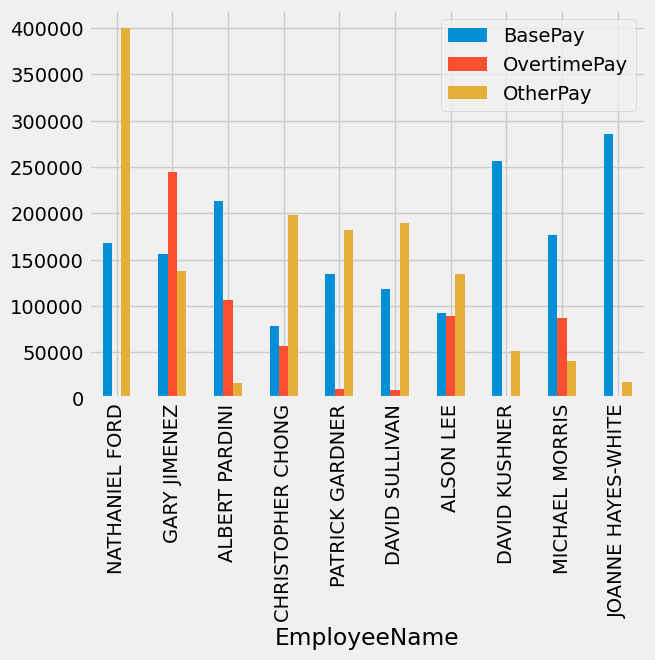

In [31]:
employee_focussed.head(10).plot(kind='bar')

#### Now we will create the same bar plot but STACK it this time

<Axes: xlabel='EmployeeName'>

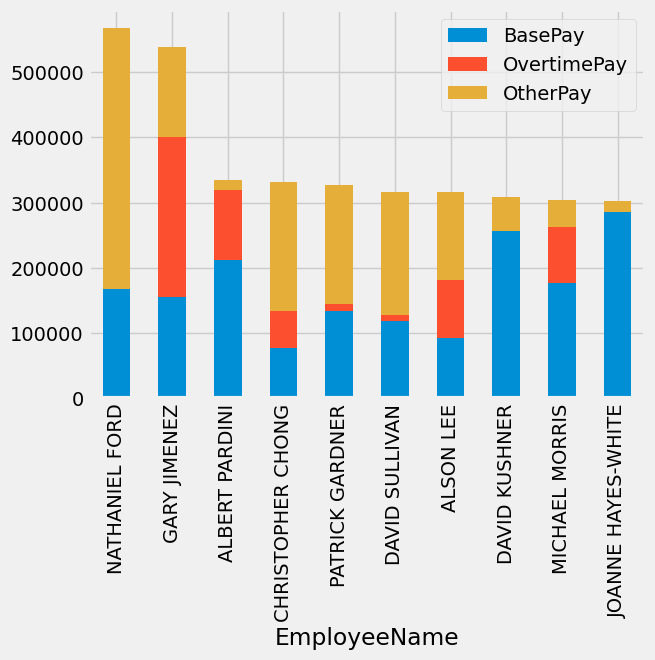

In [32]:
employee_focussed.head(10).plot(kind='bar', stacked = True)

## Instead of .plot(kind='bar'), we can use .plot.bar()

<Axes: title={'center': 'Highest Salaries'}, xlabel='EmployeeName'>

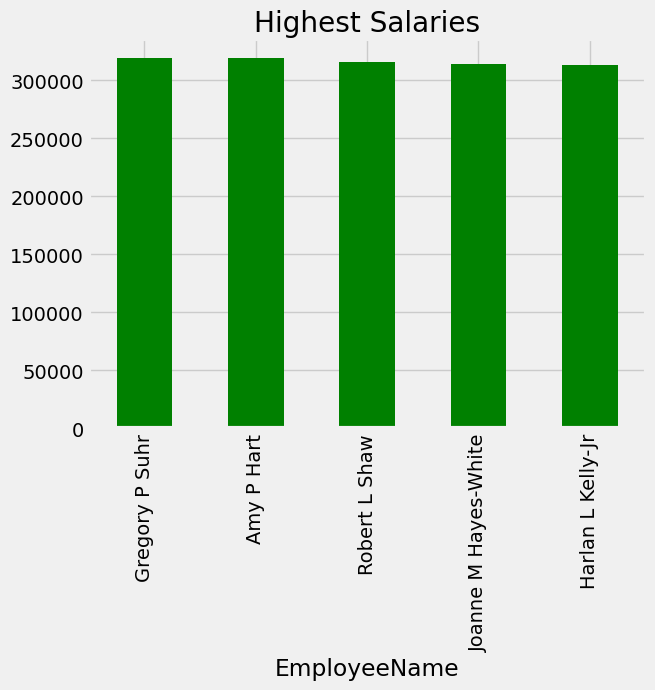

In [37]:
# employee_focussed['BasePay'].sort_values(ascending=False).head().plot(kind='bar')
employee_focussed['BasePay'].sort_values(ascending=False).head().plot.bar(
                                                                            color = 'green',
                                                                            title = 'Highest Salaries'
)

## Horizontal Bar Plots

<Axes: ylabel='EmployeeName'>

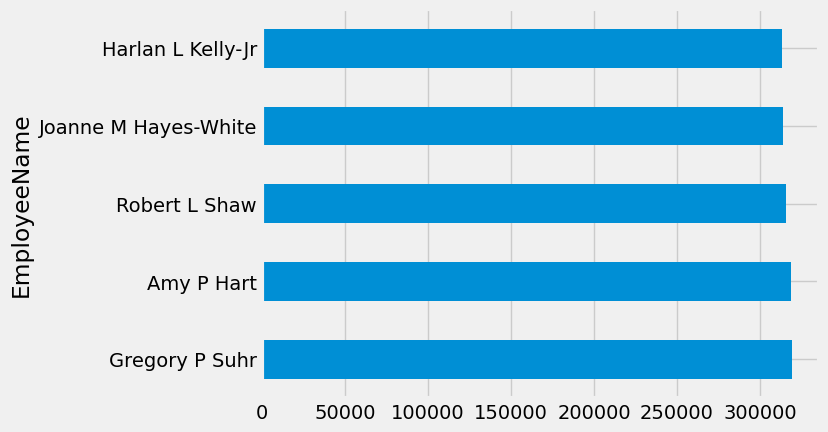

In [38]:
employee_focussed['BasePay'].sort_values(ascending=False).head().plot(kind='barh')

<Axes: ylabel='EmployeeName'>

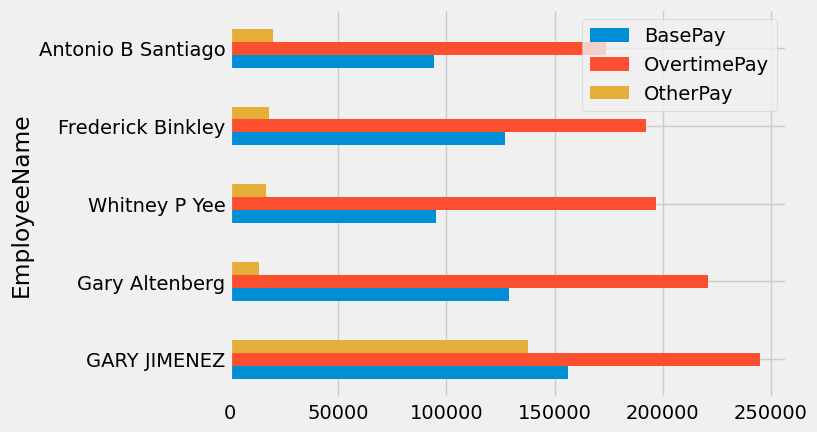

In [49]:
employee_focussed.sort_values('OvertimePay', ascending=False).head().plot(kind = 'barh')

Text(0.5, 0, 'Salary')

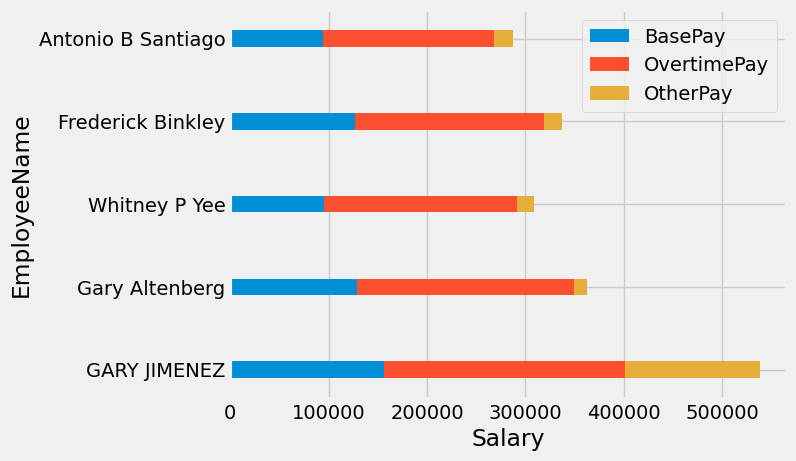

In [54]:
employee_focussed.sort_values('OvertimePay', ascending=False).head().plot(
                                                                        kind = 'barh', 
                                                                        stacked = True,
                                                                        width = 0.2)
plt.xlabel('Salary')